In [1]:
import pandas as pd

In [7]:
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
order_products = pd.read_csv('order_products__prior.csv')

In [3]:
print(orders.head(3))
print(orders.info())

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB
None


In [4]:
print(products.head(3))
print(products.info())

   product_id                          product_name  aisle_id  department_id
0           1            Chocolate Sandwich Cookies        61             19
1           2                      All-Seasons Salt       104             13
2           3  Robust Golden Unsweetened Oolong Tea        94              7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [9]:
print(order_products.head(3))
print(order_products.info())

   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB
None


In [10]:
pedidos_unicos = order_products['order_id'].unique()
print(f"Total de pedidos únicos: {len(pedidos_unicos):,}")

Total de pedidos únicos: 3,214,874


In [11]:
import numpy as np
np.random.seed(42)
amostra_pedidos = np.random.choice(pedidos_unicos, size=10000, replace=False)

In [12]:
order_products_sample = order_products[order_products['order_id'].isin(amostra_pedidos)]
print(f"\nPedidos: {len(order_products_sample['order_id'].unique()):,}")
print(f"Linhas: {len(order_products_sample):,}")


Pedidos: 10,000
Linhas: 101,404


In [13]:
order_products_with_names = order_products_sample.merge(products[['product_id', 'product_name']], on='product_id')
print(order_products_with_names.head(10))

   order_id  product_id  add_to_cart_order  reordered  \
0       231       46666                  1          1   
1       231       40203                  2          1   
2       231       45896                  3          0   
3       231       14464                  4          1   
4       231       36307                  5          0   
5       231       44254                  6          1   
6       231       25830                  7          0   
7       231       23621                  8          0   
8       231       14875                  9          1   
9       231       27845                 10          1   

                                  product_name  
0                         Rocky Road Ice Cream  
1                          Mint Chip Ice Cream  
2                  Herb Roasted Chicken Dinner  
3             Dulce de Leche Caramel Ice Cream  
4              Milano Double Chocolate Cookies  
5  White Chocolate Raspberry Truffle Ice Cream  
6                       Eggo 

In [16]:
basket['tamanho'] = basket['product_name'].apply(len)
print(basket['tamanho'].describe())

count    10000.000000
mean        10.140400
std          7.477946
min          1.000000
25%          5.000000
50%          8.000000
75%         14.000000
max         80.000000
Name: tamanho, dtype: float64


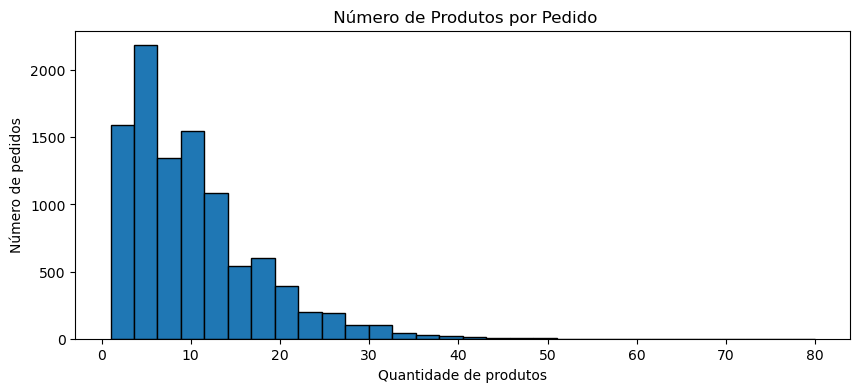

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(basket['tamanho'], bins=30, edgecolor='black')
plt.title(' Número de Produtos por Pedido')
plt.xlabel('Quantidade de produtos')
plt.ylabel('Número de pedidos')
plt.show()

In [21]:
from collections import Counter
import itertools

In [22]:
todos_produtos = [prod for cesta in basket['product_name'] for prod in cesta]
produto_contagem = Counter(todos_produtos)
print(f"Total de produtos únicos: {len(produto_contagem)}")

Total de produtos únicos: 16561


In [23]:
top_produtos = [p for p, _ in produto_contagem.most_common(50)]

In [27]:
from collections import defaultdict

pares = defaultdict(int)
total_pedidos = len(basket)

for idx, cesta in enumerate(basket['product_name']):
    if idx % 2000 == 0:
        print(f"Processando pedido {idx}/{total_pedidos}...")
    

    cesta_filtrada = [p for p in cesta if p in top_produtos]
    

    for produto1, produto2 in itertools.combinations(set(cesta_filtrada), 2):
        par = tuple(sorted([produto1, produto2]))
        pares[par] += 1

print(f"\nTotal de pares encontrados: {len(pares)}")

Processando pedido 0/10000...
Processando pedido 2000/10000...
Processando pedido 4000/10000...
Processando pedido 6000/10000...
Processando pedido 8000/10000...

Total de pares encontrados: 1211


In [28]:
resultados = []
for (prod1, prod2), count in pares.items():
    support_par = count / total_pedidos
    support_p1 = produto_contagem[prod1] / total_pedidos
    support_p2 = produto_contagem[prod2] / total_pedidos
    
    if support_p1 * support_p2 > 0:
        lift = support_par / (support_p1 * support_p2)
        confidence = count / produto_contagem[prod1]
        
        resultados.append({
            'produto_A': prod1,
            'produto_B': prod2,
            'lift': round(lift, 2),
            'confidence': round(confidence * 100, 1),
            'vezes_juntos': count,
            'suporte_A': round(support_p1 * 100, 1),
            'suporte_B': round(support_p2 * 100, 1)
        })

In [30]:
resultados_df = pd.DataFrame(resultados).sort_values('lift', ascending=False)
print(resultados_df.head(20).to_string(index=False))


                    produto_A                     produto_B  lift  confidence  vezes_juntos  suporte_A  suporte_B
Organic Italian Parsley Bunch    Organic Small Bunch Celery  7.09        16.6            34        2.1        2.3
             Organic Cucumber    Organic Small Bunch Celery  6.64        15.5            39        2.5        2.3
                    Asparagus             Fresh Cauliflower  6.19        12.7            25        2.0        2.1
                        Limes              Organic Cilantro  5.94        13.7            60        4.4        2.3
               Organic Garlic          Organic Yellow Onion  5.68        19.8            69        3.5        3.5
       Organic Grape Tomatoes       Organic Red Bell Pepper  5.37         9.6            24        2.5        1.8
                      Carrots                 Yellow Onions  5.27        12.6            31        2.5        2.4
                      Carrots    Organic Small Bunch Celery  5.21        12.2           

In [31]:
resultados_df.to_csv('regras_associacao.csv', index=False)

<Figure size 1200x800 with 0 Axes>

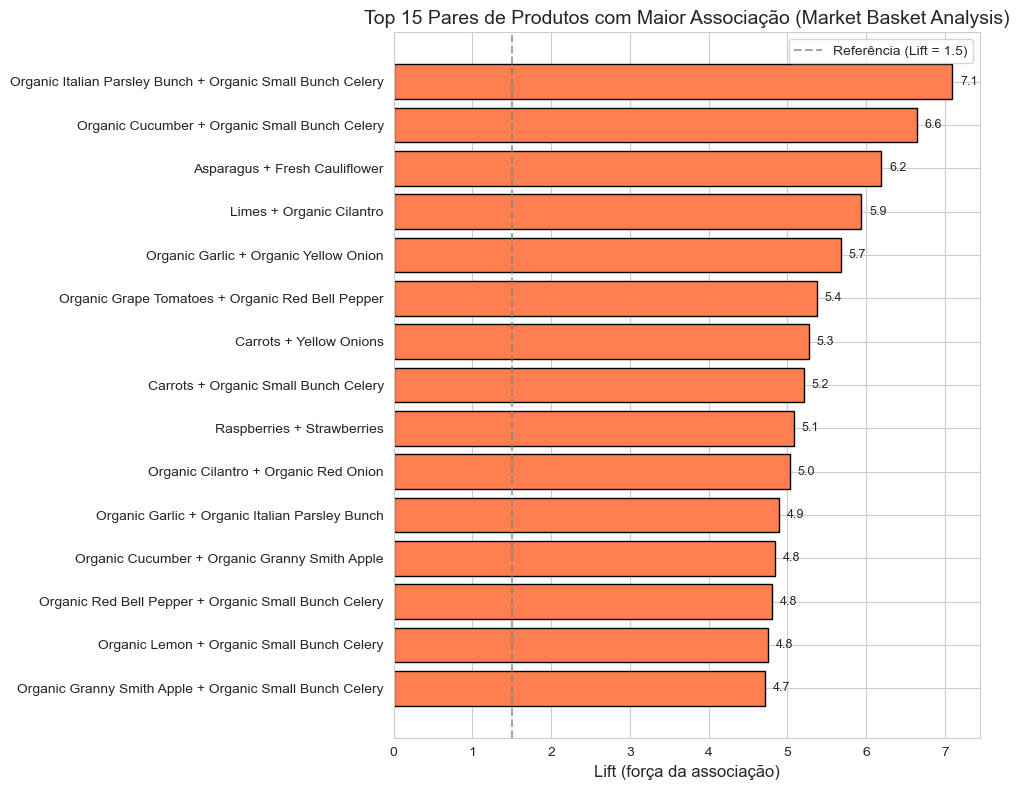

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

top15 = resultados_df.head(15).copy()  


top15['par'] = top15['produto_A'] + " + " + top15['produto_B']


plt.figure(figsize=(10, 8))
bars = plt.barh(top15['par'][::-1], top15['lift'][::-1], color='coral', edgecolor='black')
plt.xlabel('Lift (força da associação)', fontsize=12)
plt.title('Top 15 Pares de Produtos com Maior Associação (Market Basket Analysis)', fontsize=14)
plt.axvline(x=1.5, linestyle='--', color='gray', alpha=0.7, label='Referência (Lift = 1.5)')
plt.legend()

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('basket_analysis_top_rules.png', dpi=300, bbox_inches='tight')
plt.show()